# ROME: Causal Tracing and Rank-One Editing

[ROME](https://arxiv.org/abs/2202.05262) first locates factual recall with causal tracing, then changes one fact through a rank-one weight update. Here TDHook reproduces both parts on GPT-2 XL: three causal traces and ten CounterFact edits.

### Workflow and figure exports

The schematic summarizes the artifact dependencies; the executable `Workflow`
definitions appear below. Model configuration is fixed, while per-example results
pass between stages through TensorDict keys.

Every figure is displayed here and exported to `figures/` in the working
directory as an editable SVG and a 300-dpi PNG. The exported files use the same data as the inline figures.

In [1]:
from __future__ import annotations
import contextlib
import importlib.util
import io
import json
import os
from pathlib import Path
import sys
import urllib.request
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Markdown, display
from transformers import AutoModelForCausalLM, AutoTokenizer
from tensordict import TensorDict, NonTensorData
from tensordict.nn import TensorDictModule
from tdhook.workflow import Workflow

notebook_relative_dir = Path("docs/source/notebooks/tutorials")
notebook_dir = next(
    (
        root / notebook_relative_dir
        for root in (Path.cwd(), *Path.cwd().parents)
        if (root / notebook_relative_dir).is_dir()
    ),
    Path.cwd() if Path.cwd().name == "tutorials" else None,
)

In [2]:
tutorial_path = Path("docs/source/notebooks/tutorials")
tutorial_dir = next(
    (root / tutorial_path for root in (Path.cwd(), *Path.cwd().parents) if (root / tutorial_path).is_dir()), Path.cwd()
)
sys.path.insert(0, str(tutorial_dir))
from notebook_figures import STYLE, BLUE, ORANGE, TEAL, finish_figure, workflow_figure  # noqa: E402

plt.rcParams.update(STYLE)

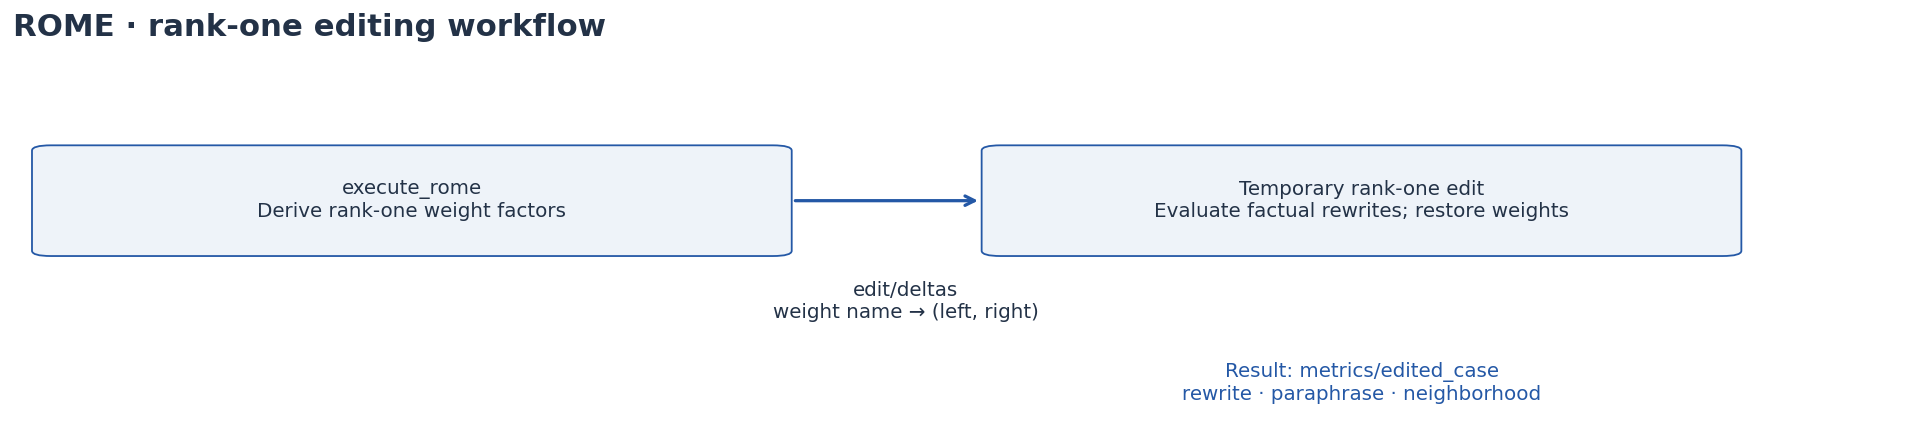

In [3]:
workflow_figure(
    "ROME · rank-one editing workflow",
    [
        "execute_rome\nDerive rank-one weight factors",
        "Temporary rank-one edit\nEvaluate factual rewrites; restore weights",
    ],
    ["edit/deltas\nweight name → (left, right)"],
    "rome-research-reproduction-workflow",
    result="Result: metrics/edited_case\nrewrite · paraphrase · neighborhood",
);

In [4]:
if notebook_dir is None:
    raise FileNotFoundError(f"Could not locate {notebook_relative_dir}")
sys.path.insert(0, str(notebook_dir))
from rome_reproduction import (  # noqa: E402
    CausalTraceConfig,
    causal_trace_grid,
    causal_trace_window_grid,
    parity_report,
    summarize_counterfact,
    temporary_rank_one_edit,
)

KNOWN_URL = "https://rome.baulab.info/data/dsets/known_1000.json"
COUNTERFACT_URL = "https://rome.baulab.info/data/dsets/counterfact.json"
data_dir = notebook_dir / "rome-data"
data_dir.mkdir(exist_ok=True)

In [5]:
def download(url, name):
    path = data_dir / name
    if not path.exists():
        urllib.request.urlretrieve(url, path)
    return json.loads(path.read_text())

In [6]:
knowns = download(KNOWN_URL, "known_1000.json")
counterfact = download(COUNTERFACT_URL, "counterfact.json")

## Load ROME and GPT-2 XL

The official ROME checkout must be available on `PYTHONPATH`. Loading the model requires CUDA and about 7 GB of downloads.

In [7]:
rome_spec = importlib.util.find_spec("rome")
if rome_spec is None or rome_spec.origin is None:
    raise ImportError("Put the official ROME checkout on PYTHONPATH")
official_root = Path(rome_spec.origin).resolve().parents[1]
cwd = Path.cwd()
try:
    os.chdir(official_root)
    from experiments.causal_trace import (
        collect_embedding_std,
        find_token_range,
        make_inputs,
        predict_from_input,
        trace_important_states,
        trace_important_window,
    )
    from experiments.py.eval_utils_counterfact import compute_rewrite_quality_counterfact
    from rome import ROMEHyperParams
    from rome.rome_main import execute_rome
finally:
    os.chdir(cwd)
if not torch.cuda.is_available():
    raise RuntimeError("GPT-2 XL requires CUDA.")
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2-xl")
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2-xl").eval().cuda()

In [8]:
model.config._name_or_path = "gpt2-xl"
for parameter in model.parameters():
    parameter.requires_grad_(False)
display(Markdown(f"**Ready:** GPT-2 XL on `{torch.cuda.get_device_name()}`"))

**Ready:** GPT-2 XL on `NVIDIA A100 80GB PCIe`

## Locate factual recall

For each prompt, TDHook constructs a two-step `Workflow`: a configured intervention corrupts the subject tokens and restores one hidden state, then a TensorDict operator computes answer recovery. The outer Python sweep invokes that workflow across token-layer locations; bright cells show where restoration recovers the original answer probability.

In [9]:
noise = 3.0 * collect_embedding_std(
    type("ModelAndTokenizer", (), {"model": model, "tokenizer": tokenizer})(),
    [item["subject"] for item in knowns],
)
trace_config = CausalTraceConfig(samples=10, noise_seed=1, noise_level=noise)
layer_paths = [f"transformer.h.{layer}" for layer in range(model.config.n_layer)]
trace_rows = []
first_heatmap = None

Define the comparison for one factual prompt, then run it on the three selected cases.

In [10]:
def trace_case(model, tokenizer, case, layer_paths, trace_config):
    """Compare residual and MLP restoration against the released implementation."""
    inputs = make_inputs(tokenizer, [case["prompt"]] * 11)
    answer_tokens, probabilities = predict_from_input(model, inputs)
    answer_token = int(answer_tokens[0])
    subject_range = find_token_range(tokenizer, inputs["input_ids"][0], case["subject"])

    official = trace_important_states(
        model, model.config.n_layer, inputs, subject_range, answer_token, noise=trace_config.noise_level
    )
    official_mlp = trace_important_window(
        model,
        model.config.n_layer,
        inputs,
        subject_range,
        answer_token,
        kind="mlp",
        window=10,
        noise=trace_config.noise_level,
    )
    tdhook = causal_trace_grid(model, inputs, answer_token, subject_range, layer_paths, config=trace_config)
    tdhook_mlp = causal_trace_window_grid(
        model, inputs, answer_token, subject_range, layer_paths, component="mlp", window=10, config=trace_config
    )
    residual_difference = parity_report(tdhook, official, atol=1e-5, rtol=1e-5)["max_abs_difference"]
    mlp_difference = parity_report(tdhook_mlp, official_mlp, atol=1e-5, rtol=1e-5)["max_abs_difference"]
    row = {
        "Prompt": case["prompt"],
        "Answer": tokenizer.decode([answer_token]).strip(),
        "Answer probability": float(probabilities[0]),
        "Max trace difference": max(residual_difference, mlp_difference),
    }
    return row, tdhook_mlp.detach().cpu(), inputs["input_ids"][0]

In [11]:
for case_id in (0, 1, 2):
    row, heatmap, input_ids = trace_case(model, tokenizer, knowns[case_id], layer_paths, trace_config)
    trace_rows.append(row)
    if first_heatmap is None:
        first_heatmap, first_inputs = heatmap, input_ids
trace_table = pd.DataFrame(trace_rows)
display(
    trace_table.style.format({"Answer probability": "{:.1%}", "Max trace difference": "{:.1e}"}).hide(axis="index")
)

Prompt,Answer,Answer probability,Max trace difference
Vinson Massif is located in the continent of,Antarctica,9.5%,1.5e-08
Beats Music is owned by,Apple,68.4%,1.2e-07
Audible.com is owned by,Amazon,25.6%,3.0e-08


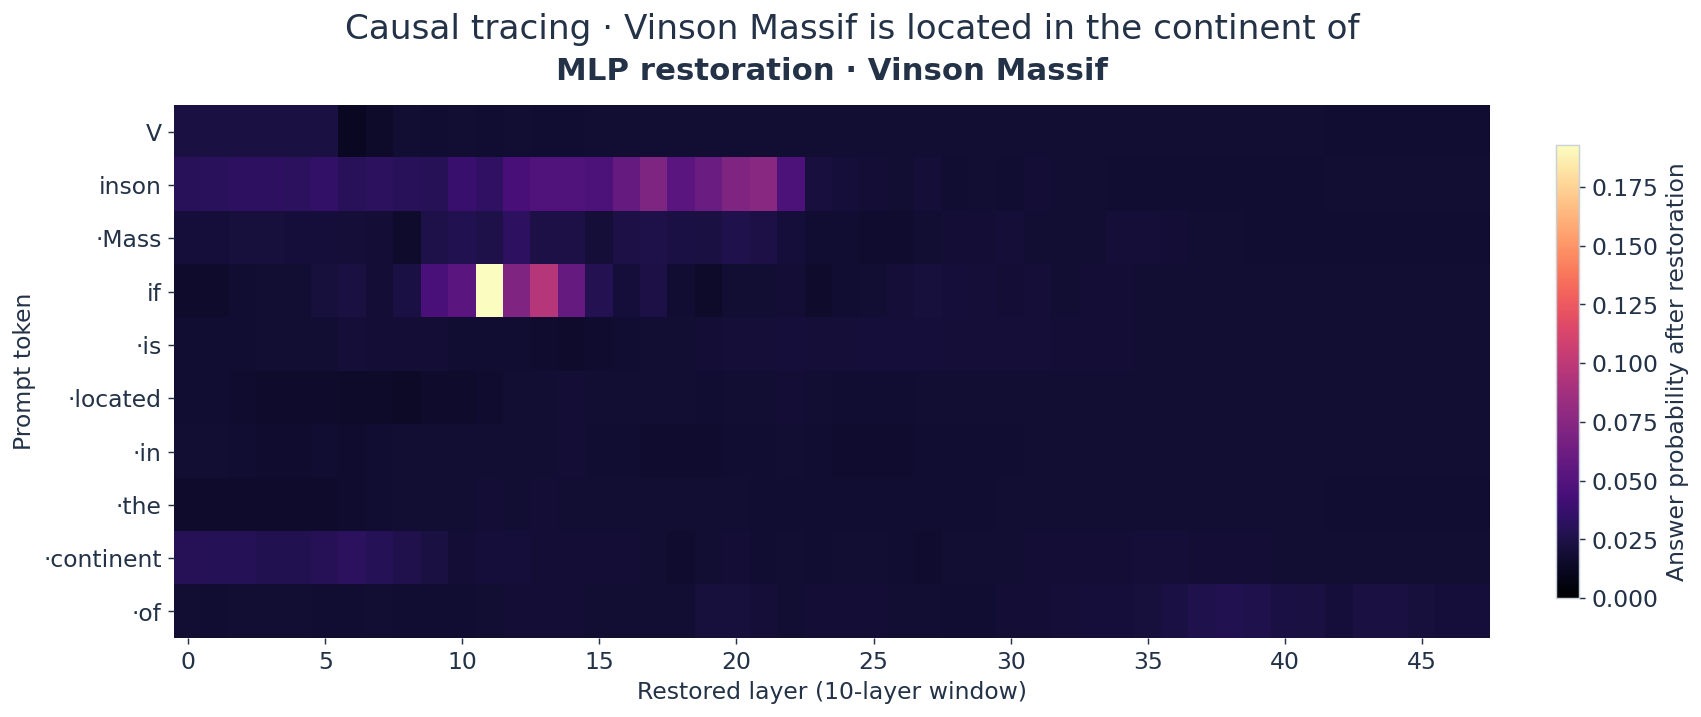

In [12]:
def plot_causal_trace(heatmap, input_ids, tokenizer, case):
    token_labels = [tokenizer.decode([int(token)]).replace(" ", "·") for token in input_ids]
    with plt.rc_context(STYLE):
        figure, axis = plt.subplots(figsize=(13, 5.4), constrained_layout=True)
        image = axis.imshow(heatmap, aspect="auto", origin="upper", cmap="magma", vmin=0)
        axis.set(
            title=f"MLP restoration · {case['subject']}",
            xlabel="Restored layer (10-layer window)",
            ylabel="Prompt token",
        )
        axis.set_yticks(range(len(token_labels)), token_labels)
        axis.set_xticks(range(0, heatmap.shape[1], 5))
        axis.spines[:].set_visible(False)
        figure.colorbar(image, ax=axis, label="Answer probability after restoration", shrink=0.85)
        figure.suptitle(f"Causal tracing · {case['prompt']}", fontsize=19)
        finish_figure(figure, "rome-causal-tracing")


plot_causal_trace(first_heatmap, first_inputs, tokenizer, knowns[0])

## Rewrite ten facts

For each CounterFact example, ROME derives a rank-one update and TDHook applies it temporarily while the official evaluator measures the edited model.

In [13]:
hparams = ROMEHyperParams.from_json(official_root / "hparams/ROME/gpt2-xl.json")

The edit workflow declares the dependency from a CounterFact record to the ROME update and from that update to temporary application and evaluation. Official ROME supplies the update and evaluator; TDHook supplies artifact composition and restoration.

In [14]:
def derive_rank_one_edit(record):
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        deltas = execute_rome(model, tokenizer, record["requested_rewrite"], hparams)
    return NonTensorData(deltas)

In [15]:
def evaluate_rank_one_edit(record, deltas):
    weight_name, (left, right) = next(iter(deltas.items()))
    module_path, parameter_name = weight_name.rsplit(".", 1)
    with temporary_rank_one_edit(model, module_path, parameter_name, left, right) as edited_model:
        post = compute_rewrite_quality_counterfact(edited_model, tokenizer, record, None, None)
    return NonTensorData({"case_id": record["case_id"], "post": post})

In [16]:
edit_workflow = Workflow(
    TensorDictModule(derive_rank_one_edit, in_keys=["record"], out_keys=[("edit", "deltas")]),
    TensorDictModule(
        evaluate_rank_one_edit, in_keys=["record", ("edit", "deltas")], out_keys=[("metrics", "edited_case")]
    ),
)

In [17]:
edited_cases = []
for record in counterfact[:10]:
    data = TensorDict({"record": NonTensorData(record)}, batch_size=[])
    result = edit_workflow(model, data)
    edited_cases.append(result["metrics", "edited_case"])
counterfact_summary = summarize_counterfact(edited_cases)

  0%|          | 0/1000 [00:00<?, ?it/s]

## What changed?

These scores describe the ten edited cases in this notebook, not the full CounterFact benchmark. Neighborhood specificity measures preservation of related facts; it is not the same as rewrite success.

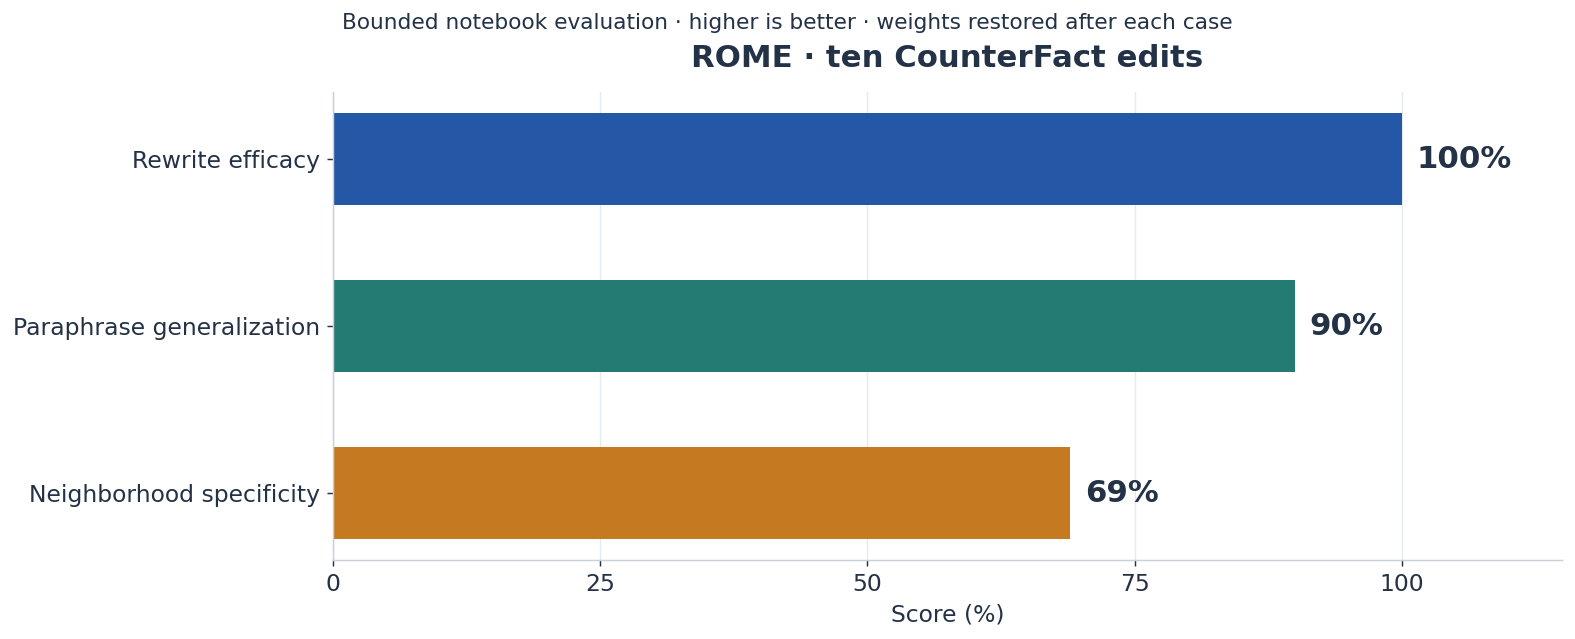

In [18]:
def plot_edit_summary(summary):
    labels = ["Rewrite efficacy", "Paraphrase generalization", "Neighborhood specificity"]
    keys = ["rewrite_efficacy", "paraphrase_generalization", "neighborhood_specificity"]
    observed = [100 * summary["metrics"][key] for key in keys]
    with plt.rc_context(STYLE):
        figure, axis = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
        bars = axis.barh(labels, observed, color=[BLUE, TEAL, ORANGE], height=0.55)
        axis.bar_label(bars, fmt="%.0f%%", padding=8, fontsize=17, fontweight="bold")
        axis.set(xlim=(0, 115), xlabel="Score (%)", title="ROME · ten CounterFact edits")
        axis.set_xticks([0, 25, 50, 75, 100])
        axis.invert_yaxis()
        axis.grid(axis="x", color="#E5EAF0", zorder=0)
        axis.set_axisbelow(True)
        figure.suptitle(
            "Bounded notebook evaluation · higher is better · weights restored after each case", fontsize=12
        )
        finish_figure(figure, "rome-edit-evaluation")


plot_edit_summary(counterfact_summary)

In [19]:
metrics = counterfact_summary["metrics"]
display(
    Markdown(
        f"Maximum difference across {len(trace_rows)} causal traces: "
        f"**{max(row['Max trace difference'] for row in trace_rows):.1e}**. "
        f"Across {len(edited_cases)} edits: efficacy **{metrics['rewrite_efficacy']:.0%}**, "
        f"paraphrase generalization **{metrics['paraphrase_generalization']:.0%}**, "
        f"neighborhood specificity **{metrics['neighborhood_specificity']:.0%}**."
    )
)

Maximum difference across 3 causal traces: **1.2e-07**. Across 10 edits: efficacy **100%**, paraphrase generalization **90%**, neighborhood specificity **69%**.

## Evaluation scope

The tracing heatmap shows answer probability after restoration, not probability
gain. Localization and editing are separate analyses here: the edit layer comes
from the released ROME hyperparameters, not automatically from the displayed
trace. The edit scores describe ten CounterFact cases, not the full benchmark.
Neighborhood specificity measures preservation of related facts, and model
weights are restored after every evaluated edit.
